In [307]:
import math
class Value:
    def __init__(self,data,_children=(),_op = '', label=''):
        self.data = data
        self.grad = 0.0
        self._backward = lambda: None
        self._prev = set(_children)
        self._op = _op
        self.label=label
        
    def __repr__(self):
        return f"Value(data={self.data})"
        
    def __add__(self,other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data + other.data,(self,other),'+')
        
        def _backward():
            self.grad += 1.0 * out.grad
            other.grad += 1.0 * out.grad
        out._backward = _backward
        return out
    def __radd__(self, other):
        return self + other
        
    def __mul__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data * other.data,(self,other),'*')
        def _backward():
            self.grad += other.data * out.grad
            other.grad += self.data * out.grad
        out._backward = _backward
        return out

    def __pow__(self,other):
        assert isinstance(other, (int, float)),"only supporting int/float powers for now"
        out = Value(self.data**other, (self,),f'**{other}')
        
        def _backward():
            self.grad += other * (self.data**(other-1)) * out.grad
        out._backward = _backward
        return out
        
    def __rmul__(self,other):
        return  self * other

    def __truediv__(self,other):
        return self * other**-1

    def __neg__(self):
        return self *-1
        
    def __sub__(self, other):
        return self + (-other)
            
    def tanh(self):
        x = self.data
        t = math.tanh(x)
        out = Value(t, (self, ),'tanh')
        
        def _backward():
            self.grad += (1 - t**2) * out.grad
        out._backward = _backward
        return out
    
    def exp(self):
        x = self.data
        out = Value(math.exp(x),(self, ),'exp')
        
        def _backward():
            self.grad += out.data * out.grad
        out._backward = _backward
        return out
        
    def backward(self):
        topo = []
        visited = set()
    
        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v)
        build_topo(self)
        
        self.grad = 1.0
        for node in reversed(topo):
            node._backward()


In [2]:
    
a = Value(2.0, label='a')
b= Value(-3.0, label='b')
c = Value(10.0, label='c')
e = a*b; e.label ='e'
d = e +c; d.label ='d'
f = Value(-2.0,label='f')
L = d*f; L.label='L'
print(L)

Value(data=-8.0)


In [3]:
pip install graphviz

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: C:\Program Files\Python312\python.exe -m pip install --upgrade pip


In [4]:
a+2
a-b
c = a/b
2*a


Value(data=4.0)

In [5]:
from graphviz import Digraph

def trace(root):
    nodes, edges = set(), set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child,v))
                build(child)
    build(root)
    return nodes, edges
        
def draw_dot(root):
    dot = Digraph(format ='svg', graph_attr={'rankdir':'LR'})

    nodes,edges = trace(root)
    for n in nodes:
        uid = str(id(n))
        dot.node(name = uid, label = "{%s | data %.4f | grad %.4f}" % (n.label, n.data, n.grad), shape = 'record')
        if n._op:
            dot.node(name = uid + n._op, label = n._op)
            dot.edge(uid + n._op, uid)
    for n1, n2 in edges:
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)
    return dot

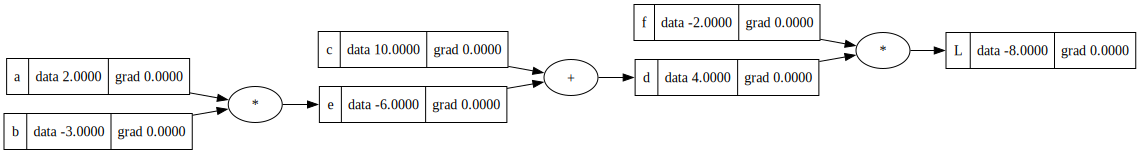

In [6]:
draw_dot(L)

In [7]:
a.grad = -2.0 * -3.0
b.grad = -2.0 * 2.0

In [8]:
def lol():
    
    h= 200
    
    a = Value(2.0, label='a') 
    b= Value(-3.0, label='b')
    c = Value(10.0, label='c')
    e = a*b; e.label ='e'
    d = e +c; d.label ='d'
    f = Value(-2.0,label='f')
    L = d*f; L.label='L'
    L1 = L.data
    
    a = Value(2.0, label='a')
    b= Value(-3.0, label='b')
    c = Value(10.0, label='c')
    
    e = a*b; e.label ='e'

    d = e +c; d.label ='d'
    f = Value(-2.0 ,label='f')
    L = d*f; L.label='L'
    L2 = L.data+h
    print((L2-L1)/h)
lol()

1.0


In [9]:
# inputs
x1 = Value(2.0,label='x1')
x2 = Value(0.0,label='x2')
#weights
w1 = Value(-3.0,label='w1')
w2 = Value(1.0,label='w1')
b = Value(6.8813735870195432,label = 'b')
#x1*w1 + x2*w2 +b
x1w1 = x1*w1; x1w1.label = 'x1*w1'
x2w2 = x2*w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label ='x1*w1 + x2*w2'
n = x1w1x2w2 + b; n.label = 'n'
o = n.tanh()
o.label='o'



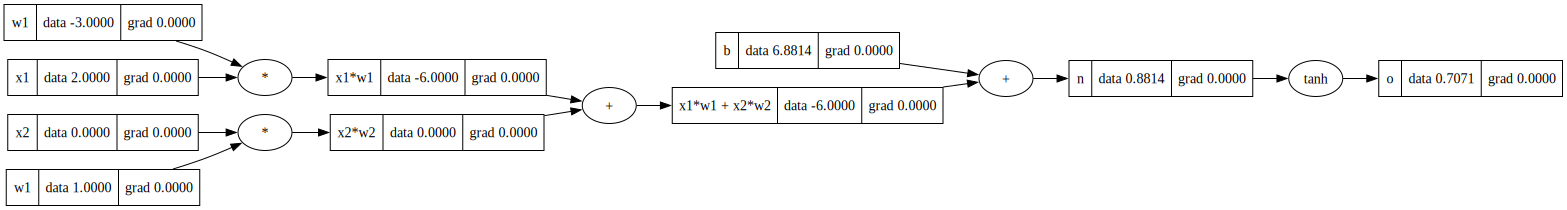

In [10]:
draw_dot(o)

In [11]:
o.backward()

In [12]:
# o.grad = 1.0
# o._backward()

In [13]:
# n._backward()

In [14]:
# b._backward()

In [15]:
# x1w1x2w2._backward()

In [16]:
# x2w2._backward()

In [17]:
# x1w1._backward()

In [18]:
# x1.grad = w1.data * x1w1.grad
# w1.grad = x1.data * x1w1.grad

In [19]:
# x2.grad = w2.data * x2w2.grad
# w2.grad = x2.data * x2w2.grad

In [20]:
# x1w1.grad = 0.5
# x2w2.grad = 0.5

In [21]:
# x1w1x2w2.grad = 0.5
# b.grad = .5

In [22]:
# n.grad = 0.5

In [23]:
# o.grad =1.0

In [24]:
# 1- o.data**2

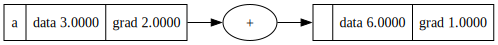

In [25]:
a= Value(3.0, label='a')
b = a+a
b.backward()
draw_dot(b)

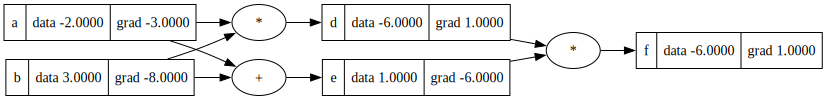

In [26]:
a = Value(-2.0, label = 'a')
b = Value(3.0, label = 'b')
d = a*b ; d.label = 'd'
e = a+b ; e.label = 'e'
f = d*e ; f.label = 'f'
f.backward()
draw_dot(f)

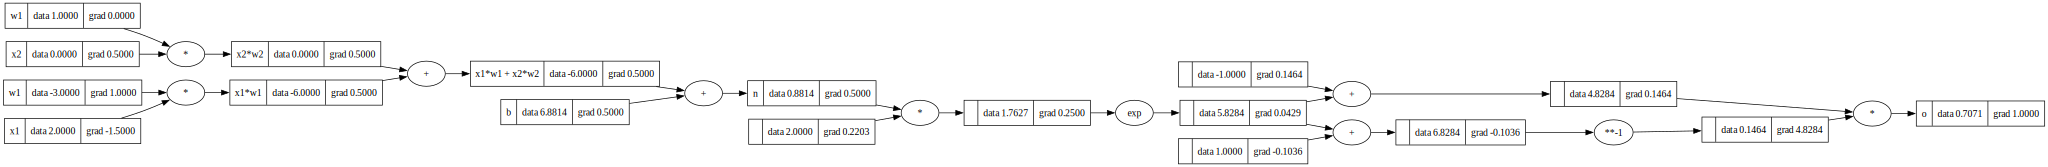

In [27]:
# inputs
x1 = Value(2.0,label='x1')
x2 = Value(0.0,label='x2')
#weights
w1 = Value(-3.0,label='w1')
w2 = Value(1.0,label='w1')
b = Value(6.8813735870195432,label = 'b')
#x1*w1 + x2*w2 +b
x1w1 = x1*w1; x1w1.label = 'x1*w1'
x2w2 = x2*w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label ='x1*w1 + x2*w2'
n = x1w1x2w2 + b; n.label = 'n'

e = (2*n).exp()

o = (e-1)/(e+1)

o.label='o'

o.backward()
draw_dot(o)


In [28]:
pip install torch ipykernel

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: C:\Program Files\Python312\python.exe -m pip install --upgrade pip


In [29]:
python -m ipykernel install --user --name myenv

SyntaxError: invalid syntax (783746406.py, line 1)

In [30]:
import torch


In [31]:
x1 = torch.Tensor([2.0]).double() ; x1.requires_grad = True
x2 = torch.Tensor([0.0]).double() ; x2.requires_grad = True
w1 = torch.Tensor([-3.0]).double() ; w1.requires_grad = True
w2 = torch.Tensor([1.0]).double() ; w2.requires_grad = True
b = torch.Tensor([6.8813735870195432]).double() ; b.requires_grad = True
n = x1*w1 + x2*w2 +b
o = torch.tanh(n)

print(o.data.item())
o.backward()

print('-------')
print('x2', x2.grad.item())
print('w2', w2.grad.item())
print('x1', x1.grad.item())
print('w1', w1.grad.item())

0.7071066904050358
-------
x2 0.5000001283844369
w2 0.0
x1 -1.5000003851533106
w1 1.0000002567688737


In [32]:
o

tensor([0.7071], dtype=torch.float64, grad_fn=<TanhBackward0>)

In [115]:
import random
class Neuron:
    
    def __init__(self, nin):
        self.w = [Value(random.uniform(-1,1)) for _ in range(nin)]
        self.b = Value(random.uniform(-1,1))
    def __call__(self,x):

        act = sum((wi*xi for wi, xi in zip(self.w,x)), self.b)
        out = act.tanh()
        return out
        return
        
    def parameters(self):
        return self.w + [self.b]
        
class Layer:

    def __init__(self, nin, nout):
        self.neurons = [Neuron(nin) for _ in range(nout)]
    def __call__(self,x):
            outs = [n(x) for n in self.neurons]
            return outs[0] if len(outs) == 1 else outs

    def parameters(self):
        return [p for neuron in self.neurons for p in neuron.parameters()]
        
        params = []
        #for neuron in self.neurons:
         #   ps = neuron.parameters()
          #  params.extend(ps)

class MLP:

    def __init__(self,nin,nouts):
        sz = [nin] + nouts
        self.layers = [Layer(sz[i], sz[i+1]) for i in range(len(nouts))]

    def __call__(self, x):
        for layer in self.layers:
            x = layer(x)
        return x
    def parameters(self):
        return [p for layer in self.layers for p in layer.parameters()]


x = [2.0, 3.0, -1.0]

n =MLP(3, [4,4,1])
n(x)

Value(data=-0.295210313832023)

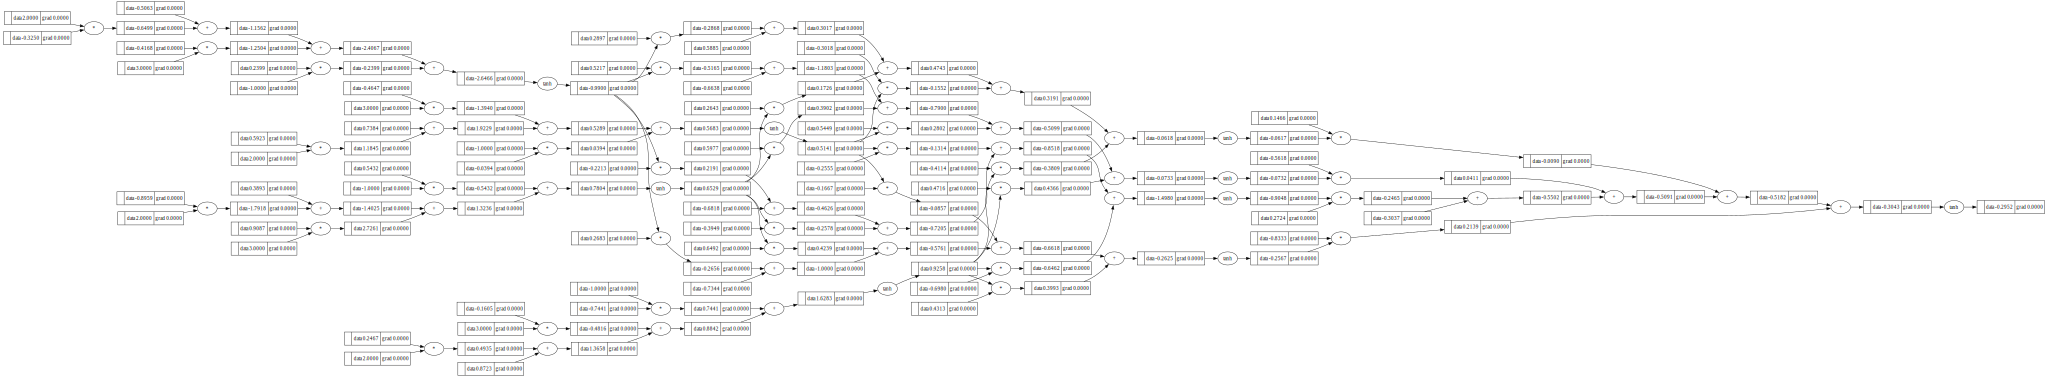

In [116]:
draw_dot(n(x))

In [305]:
xs = [
    [2.0,3.0,-1.0],
    [3.0,-1.0,0.5],
    [0.5,1.0,1.0],
    [1.0,1.0,-1.0],
]

ys = [1.0,-1.0,-1.0, 1.0] #targets

#ypred = [n(x) for x in xs]
#ypred

In [309]:
for k in range(20):
    #forward pass
    ypred = [n(x) for x in xs]
    loss = sum((yout - ygt)**2 for ygt, yout in zip(ys,ypred))

    #backward
    for p in n.parameters():
        p.grad = 0.0
    loss.backward()

    #update
    for p in n.parameters():
        p.data += -0.05 * p.grad
    print(k, loss.data)

0 0.00011849498875634147
1 0.00011842404785667387
2 0.00011835318782941533
3 0.00011828240853772866
4 0.00011821170984508063
5 0.00011814109161524641
6 0.00011807055371230424
7 0.00011800009600064225
8 0.0001179297183449459
9 0.00011785942061020965
10 0.00011778920266171966
11 0.00011771906436507976
12 0.00011764900558617976
13 0.0001175790261912167
14 0.00011750912604668229
15 0.0001174393050193722
16 0.00011736956297637111
17 0.00011729989978506436
18 0.00011723031531313744
19 0.00011716080942856127


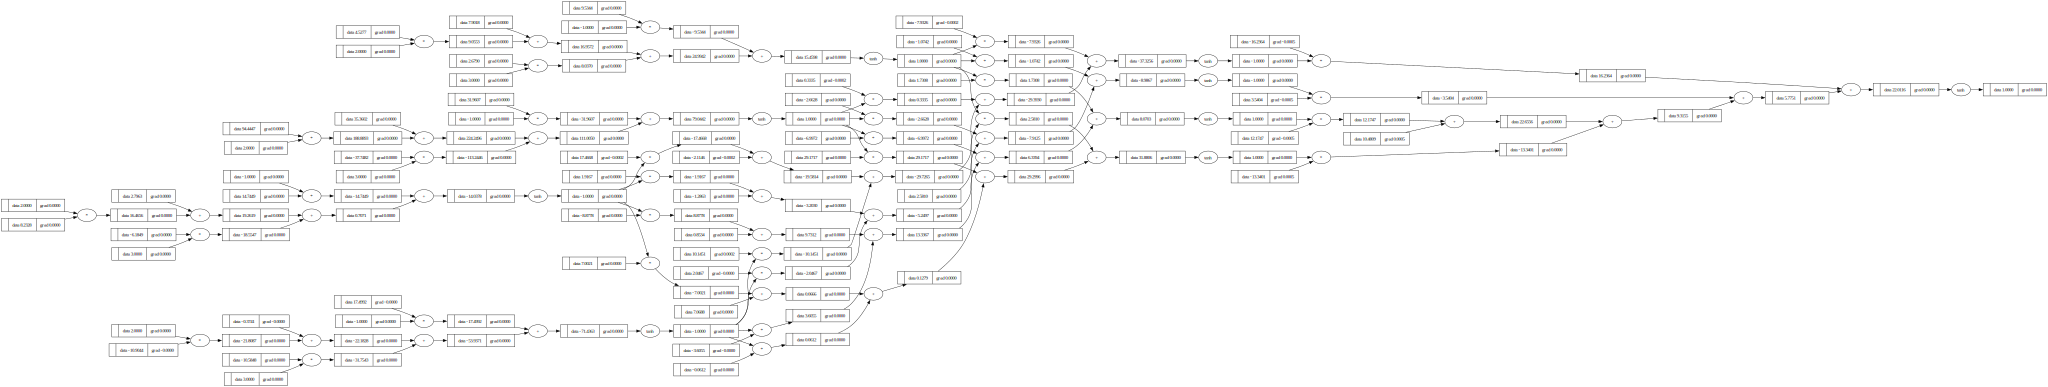

In [311]:
ypred
draw_dot(n(x))

In [297]:
ypred = [n(x) for x in xs]
loss = sum((yout - ygt)**2 for ygt, yout in zip(ys, ypred))
loss

Value(data=0.0)

In [294]:
loss.backward()

In [295]:
for p in n.parameters():
    p.data -= -0.1 * p.grad

In [298]:
ypred

[Value(data=1.0), Value(data=-1.0), Value(data=-1.0), Value(data=1.0)]

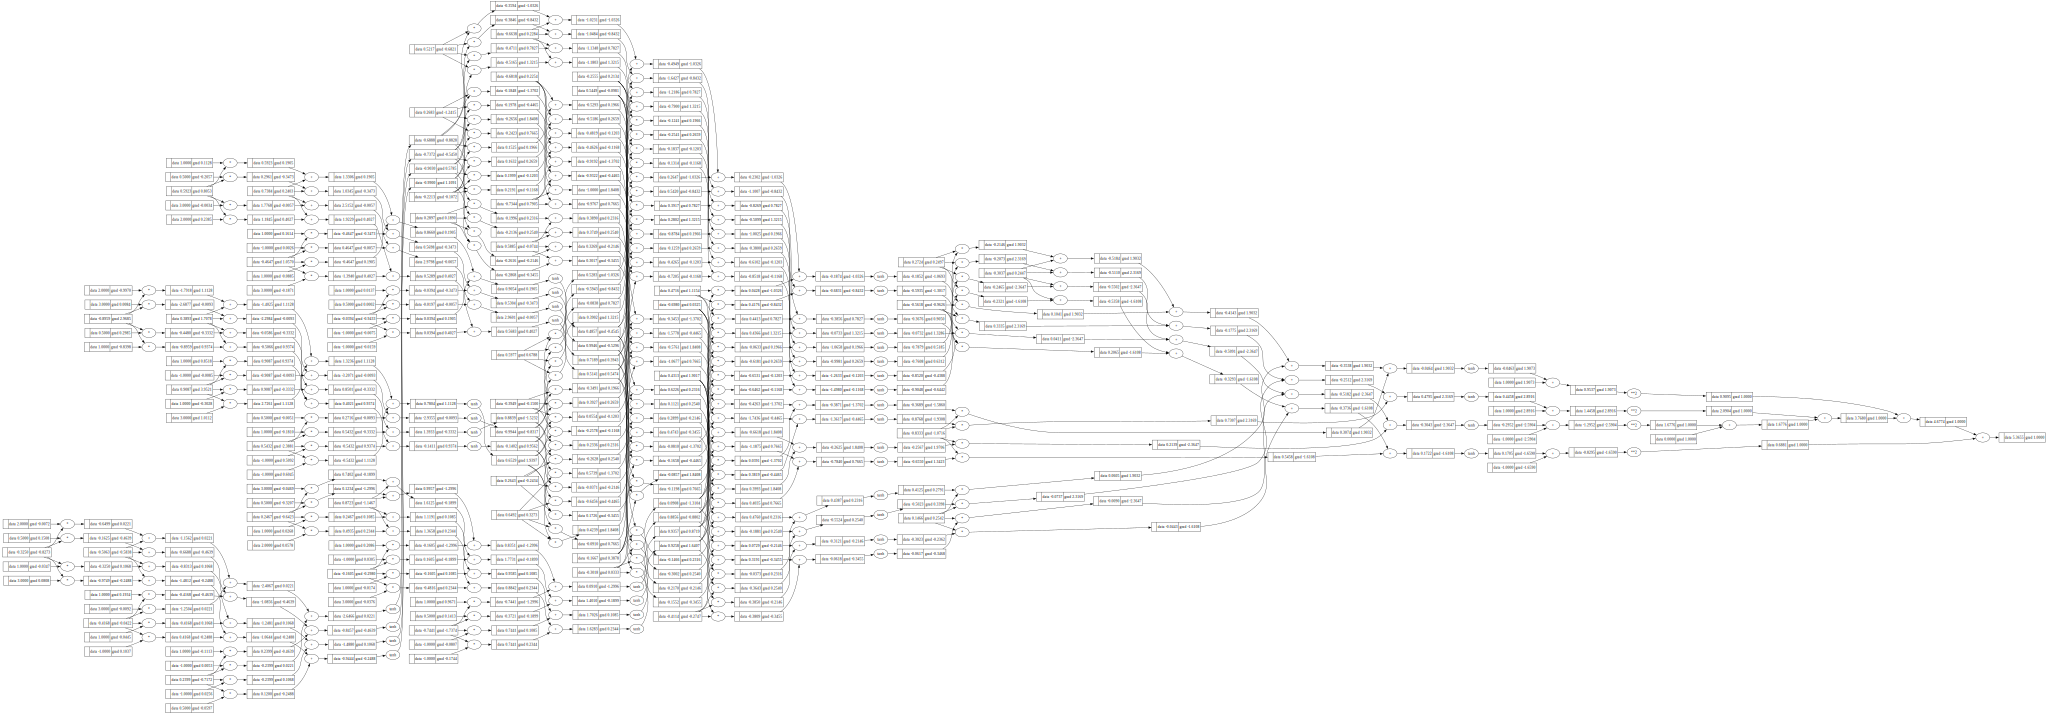

In [121]:
draw_dot(loss)

In [123]:
len(n.parameters())

41

In [126]:
n.layers[0].neurons[0].w[0].data

-0.3166777438817576